## Import Libraries

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install rapidfuzz
from rapidfuzz import process, fuzz
from scipy.stats import chi2_contingency

from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Data Loading

In [130]:
df = pd.read_csv("Bangladesh_Crime_Dataset_B.csv")

In [131]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.head()

,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,incident_district,incident_division,precip,visibility,heatindex,season,male_population,female_population,total_population,gender_ration,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college,crime
0,0,7,29,wednesday,0,morning,dhaka,dhaka,6.1,10,32,rainy,4931802,3974237,8906039,125,8.42,30551,74.6,4289,99,17,60,242,64,murder
1,1,1,2,wednesday,0,night,dhaka,dhaka,0.0,10,22,winter,4931802,3974237,8906039,125,8.42,30551,74.6,4289,99,17,60,242,64,murder
2,2,1,4,tuesday,0,night,dhaka,dhaka,0.0,10,25,winter,4931802,3974237,8906039,125,8.42,30551,74.6,4289,99,17,60,242,64,murder
3,3,3,9,friday,1,night,dhaka,dhaka,0.0,10,30,hot,4931802,3974237,8906039,125,8.42,30551,74.6,4289,99,17,60,242,64,murder
4,4,8,34,thursday,0,night,dhaka,dhaka,21.9,9,38,rainy,4931802,3974237,8906039,125,8.42,30551,74.6,4289,99,17,60,242,64,murder


## Data Understanding and Preprocessing

### Columns in Dataset

In [132]:
df.columns

Index(['Unnamed: 0', 'incident_month', 'incident_week', 'incident_weekday',
       'weekend', 'part_of_the_day', 'incident_district', 'incident_division',
       'precip', 'visibility', 'heatindex', 'season', 'male_population',
       'female_population', 'total_population', 'gender_ration',
       'average_household_size', 'density_per_kmsq', 'literacy_rate',
       'religious_institution', 'playground', 'park', 'police_station',
       'school', 'college', 'crime'],
      dtype='object')

### Handling Column Name

In [133]:
df = df.rename(columns={'gender_ration': 'gender_ratio'})

Terdapat **kesalahan penamaan variabel** **"gender_ration"** yang seharusnya **"gender_ratio"**.

### Check Data Dimension and Data Types

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              6574 non-null   int64  
 1   incident_month          6574 non-null   int64  
 2   incident_week           6574 non-null   int64  
 3   incident_weekday        6574 non-null   object 
 4   weekend                 6574 non-null   int64  
 5   part_of_the_day         6457 non-null   object 
 6   incident_district       6574 non-null   object 
 7   incident_division       6574 non-null   object 
 8   precip                  5917 non-null   float64
 9   visibility              6574 non-null   int64  
 10  heatindex               6574 non-null   int64  
 11  season                  6246 non-null   object 
 12  male_population         6574 non-null   int64  
 13  female_population       6574 non-null   int64  
 14  total_population        6574 non-null   

Dataset ini terdiri dari **6574 baris dan 26 kolom**. Dataset ini mencakup kombinasi variabel waktu, lokasi, kondisi cuaca, demografi, infrastruktur, serta kategori kejahatan. Berdasarkan hasil pemeriksaan, **tidak ditemukan adanya kesalahan tipe data**, seluruh variabel telat tersimpan dalam tipe data yang sesuai.   

Dataset ini mengandung beberapa kolom dengan **missing values**, yaitu **"part_of_the_day", "precip", "season", "literacy_rate"**.  Proporsi **missing values pada masing-masing kolom relatif kecil** dibandingkan dengan total jumlah data. Oleh karena itu, **penanganan missing values nantinya akan dilakukan menggunakan teknik imputasi** seperti imputasi **median / mean** untuk variabel **numerik** dan imputasi **modus** untuk variabel **kategorikal**.

Selain itu, juga terdapat **fitur tidak informatif** yaitu kolom **"Unnamed: 0"** yang teridentifikasi sebagai **kolom indeks** yang tidak memiliki nilai informatif untuk analisis pemodelan. Oleh karena itu, kolom ini akan **dihapus pada tahap preprocessing**.

### Check Duplicate

In [135]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  0


**Tidak ada data duplikat.**

### Check Inconsistent

In [136]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  400
incident_weekday
tuesday      912
wednesday    890
monday       889
thursday     837
saturday     822
            ... 
snnday         1
hsaturday      1
thuasday       1
sunmday        1
tlesday        1
Name: count, Length: 400, dtype: int64

Total Unique Values :  5
part_of_the_day
night        3179
morning      1946
noon          517
evening       484
afternoon     331
Name: count, dtype: int64

Total Unique Values :  64
incident_district
dhaka         1169
chattogram     491
mymensingh     269
jashore        261
dinajpur       209
              ... 
magura          17
sherpur         16
shariatpur      15
kurigram        10
narail          10
Name: count, Length: 64, dtype: int64

Total Unique Values :  9
incident_division
dhaka         2046
chattogram    1061
rajshahi       782
rangpur        703
khulna         697
mymensingh     449
sylhet         424
barisal        408
gazipur          4
Name: count, dtype: int64

Total Unique Values :  3
season
rainy 

Pemeriksaan konsistensi data kategorikal menunjukkan adanya **ketidakkonsistenan yang signifikan** pada variabel **"incident_weekday"**, yang memiliki **400 nilai unik**, **jauh melebihi jumlah kategori yang seharusnya**, yaitu **7 hari dalam satu minggu**. Ketidakkonsistenan ini disebabkan oleh variasi penulisan dan kesalahan ejaan (typo) yang menyebabkan satu hari direpresentasikan dalam banyak bentuk berbeda. Oleh karena itu, seluruh nilai pada variabel incident_weekday perlu distandarisasi dan **dipetakan ke tujuh kategori hari yang valid (Senin hingga Minggu)** untuk mengurangi noise dan redundansi data.

Sementara itu, **variabel kategorikal lainnya** menunjukkan kategori yang **relatif jelas dan konsisten** serta tidak mengandung nilai ambigu maupun tidak valid. Meskipun demikian, beberapa fitur tetap perlu diperhatikan pada **tahap prapemrosesan selanjutnya**, khususnya dalam proses **normalisasi, standarisasi, dan encoding**, guna memastikan bahwa seluruh variabel siap digunakan secara optimal dalam analisis lanjutan dan pemodelan machine learning.

### Handling Inconsistencies

In [137]:
df['incident_weekday'] = (
    df['incident_weekday']
    .str.lower()
    .str.strip()
)

valid_weekdays = [
    'monday', 'tuesday', 'wednesday',
    'thursday', 'friday', 'saturday', 'sunday'
]

In [138]:
def correct_weekday(value, choices, threshold=80):
    if pd.isna(value):
        return value

    match, score, _ = process.extractOne(
        value,
        choices,
        scorer=fuzz.ratio
    )

    return match if score >= threshold else None

In [139]:
df['incident_weekday'] = df['incident_weekday'].apply(
    lambda x: correct_weekday(x, valid_weekdays)
)

In [140]:
df['incident_weekday'].value_counts()

,count
incident_weekday,
tuesday,1010
monday,984
wednesday,976
thursday,937
saturday,917
friday,883
sunday,867


Penanganan **inkonsistensi** pada variabel **incident_weekday** dilakukan menggunakan pendekatan **fuzzy string matching**, yang memungkinkan sistem secara **otomatis mengidentifikasi dan memperbaiki kesalahan ejaan serta variasi penulisan berdasarkan tingkat kemiripan string**. Pendekatan ini lebih efisien dan robust dibandingkan pemetaan manual, terutama ketika jumlah variasi penulisan sangat besar.

### Check Invalid Values

In [141]:
df.describe()

,Unnamed: 0,incident_month,incident_week,weekend,precip,visibility,heatindex,male_population,female_population,total_population,gender_ratio,average_household_size,density_per_kmsq,literacy_rate,religious_institution,playground,park,police_station,school,college
count,6574.000000,6574.000000,6574.000000,6574.000000,5917.000000,6574.000000,6574.000000,6.574000e+03,6.574000e+03,6.574000e+03,6574.000000,6574.000000,6574.000000,6246.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000,6574.000000
mean,3286.500000,6.193185,25.193946,0.273806,6.136775,9.488287,31.597657,8.936342e+05,7.544586e+05,1.648104e+06,104.429723,4.965023,6362.512017,55.742683,1219.757073,42.504411,3.863706,11.762093,75.218893,15.479617
std,1897.894667,3.321934,14.517965,0.445944,11.778346,0.922742,5.502593,1.605205e+06,1.284180e+06,2.889245e+06,10.387173,1.422850,10368.342248,12.082504,1246.313725,44.857967,5.883186,19.604510,71.743767,19.721917
min,0.000000,1.000000,1.000000,0.000000,0.000000,4.000000,15.000000,1.132000e+04,1.124700e+04,2.287100e+04,84.000000,3.580000,23.000000,26.700000,-99.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,1643.250000,3.000000,13.000000,0.000000,0.000000,9.000000,27.000000,1.319300e+05,1.339960e+05,2.652760e+05,98.000000,4.110000,924.000000,46.600000,509.500000,5.000000,0.000000,2.000000,30.000000,4.000000
50%,3286.500000,6.000000,25.000000,0.000000,0.800000,10.000000,33.000000,1.872290e+05,1.870170e+05,3.765500e+05,101.000000,4.440000,1239.000000,53.900000,797.000000,25.000000,1.000000,3.000000,45.000000,8.000000
75%,4929.750000,9.000000,37.000000,1.000000,7.400000,10.000000,36.000000,3.917070e+05,3.811572e+05,7.757330e+05,109.000000,5.100000,3977.000000,67.200000,1121.000000,78.000000,3.000000,6.000000,86.000000,15.000000
max,6573.000000,12.000000,53.000000,1.000000,204.600000,10.000000,43.000000,4.931802e+06,3.974237e+06,8.906039e+06,203.000000,8.420000,30551.000000,74.600000,4289.000000,253.000000,17.000000,74.000000,242.000000,64.000000


Berdasarkan hasil analisis statistik deskriptif, **sebagian besar variabel** numerik **berada dalam rentang nilai yang logis dan realistis**, namum terdapat **beberapa nilai yang tidak valid** dan berpotensi merupakan anomali data yang perlu ditangani, yaitu :    
- Variabel **"religious_institution"** memiliki nilai minimum **-99**, yang secara logika tidak mungkin terjadi karena jumlah institusi keagamaan tidak dapat bernilai negatif.
- Variabel **"police_station"** menunjukkan nilai minimum **-1**, yang juga merupakan nilai tidak valid.   

Nilai tidak valid yang teridentifikasi ini nantinya akan **ditangani dengan mengganti nilai-nilai tersebut menjadi missing values**, kemudian dilakukan **imputasi** menggunakan metode yang sesuai (mean/median/median)

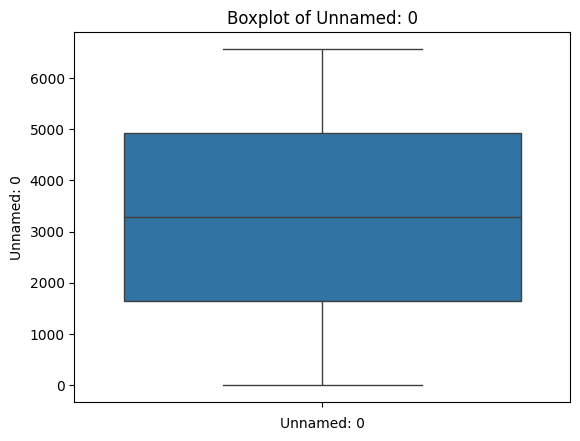

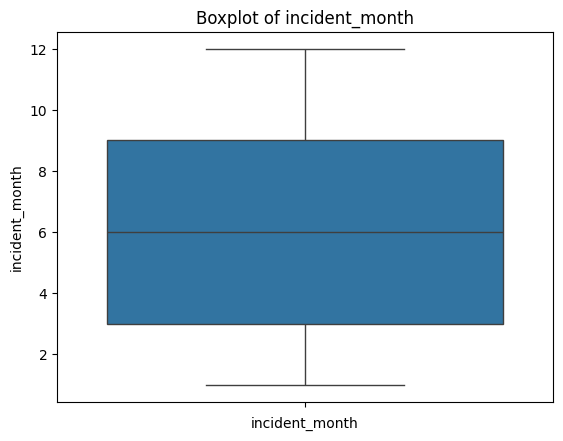

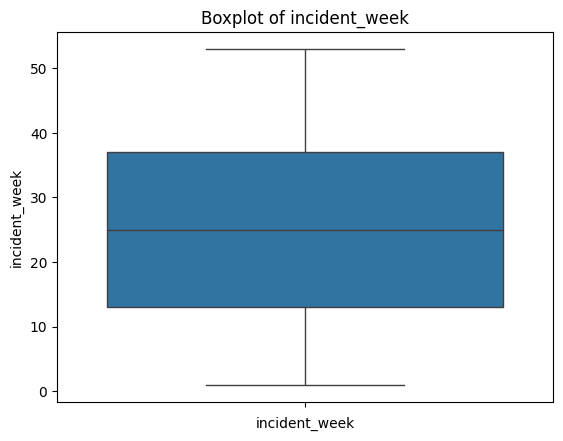

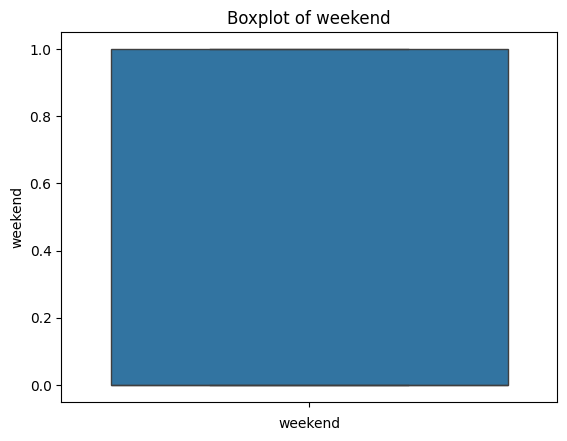

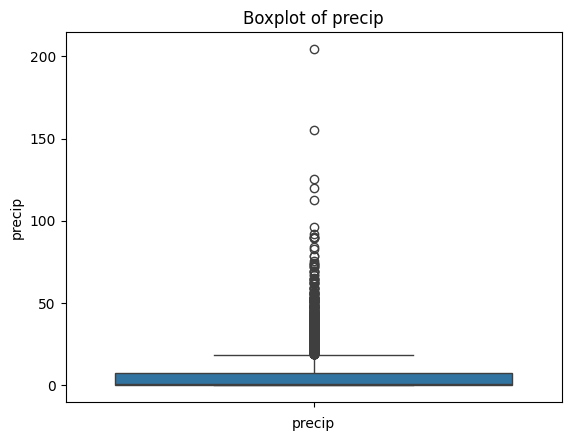

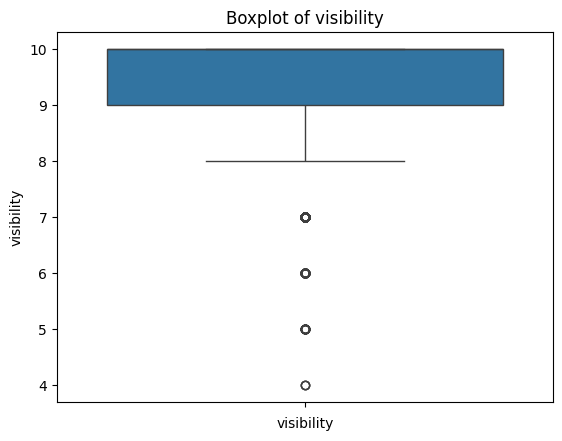

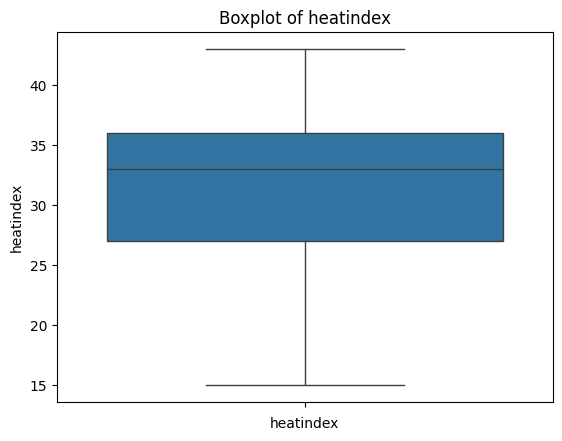

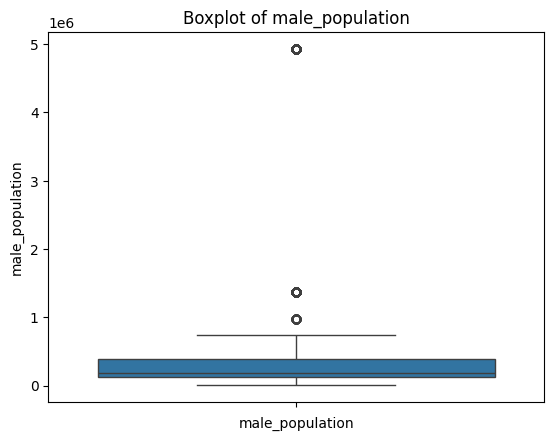

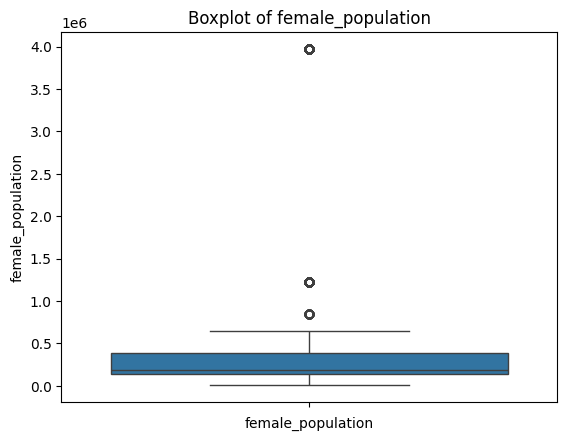

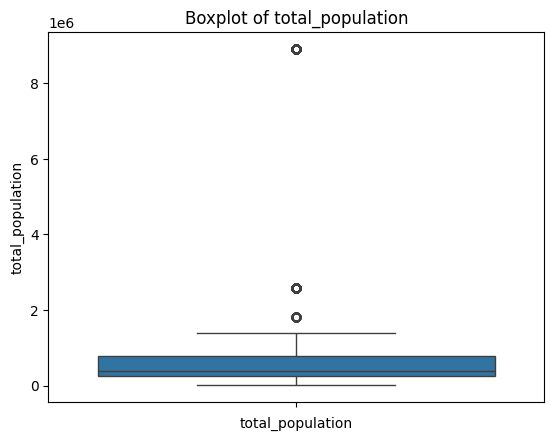

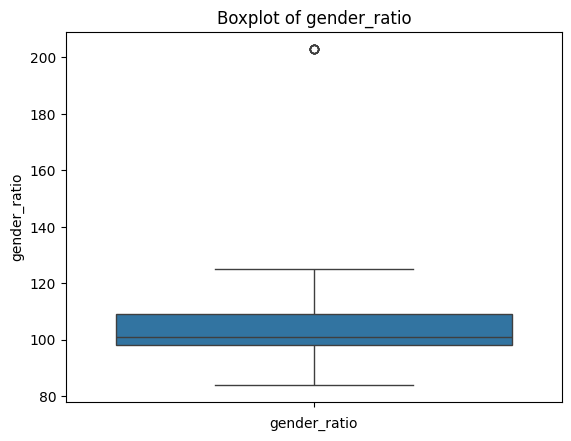

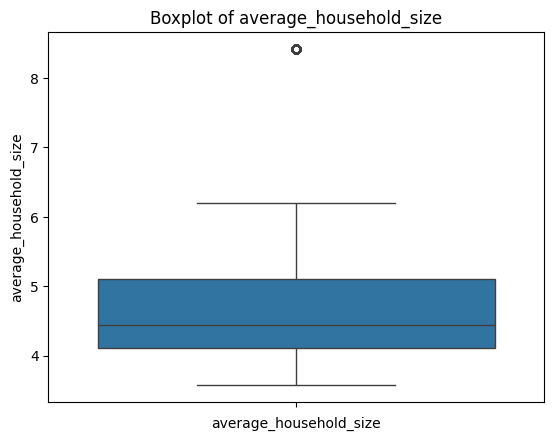

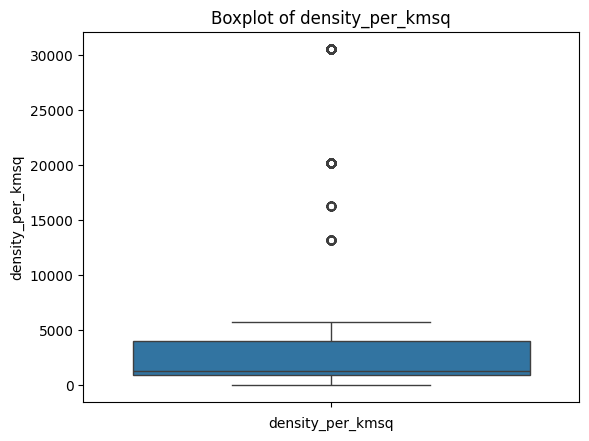

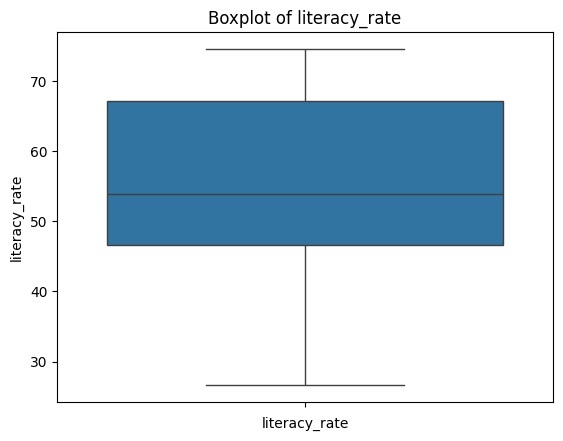

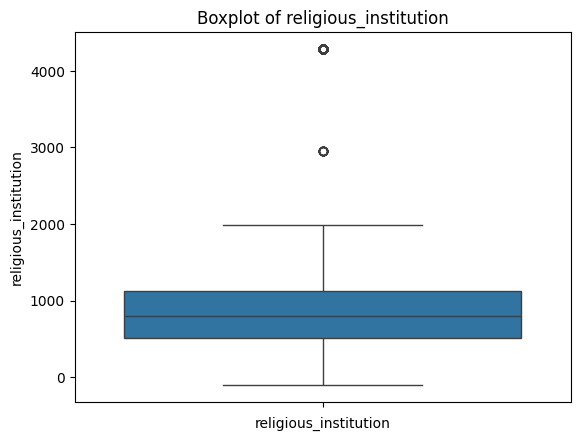

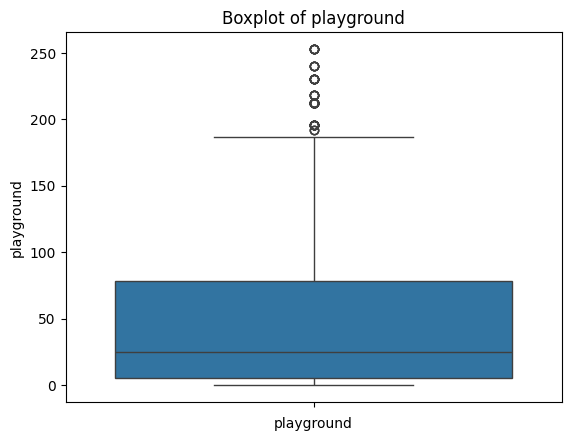

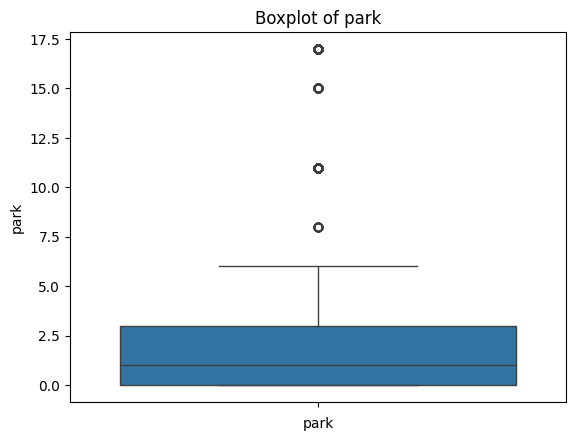

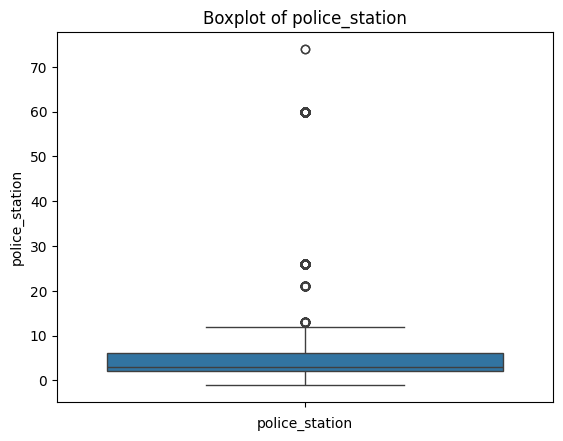

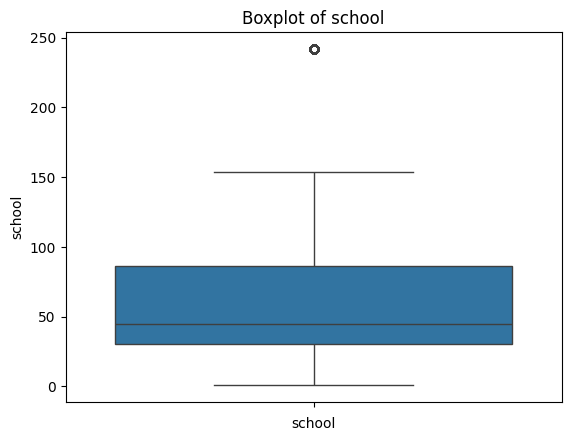

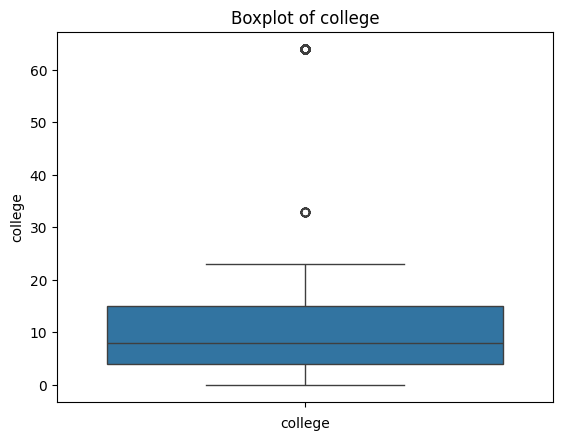

In [142]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

Terdapat **outlier** pada beberapa variabel numerik, yaitu **"precip", "visibility", "male_population", "female_population", "total_population", "gender_ratio", "average_household_size", "density_per_kmsq", "religious_institution", "playground", "park", "police_station", "school", dan "college"**. Namun demikian, **jumlah outlier pada sebagian besar variabel relatif kecil** dan masih berada dalam konteks yang **masuk akal**.

### Handling Invalid Values

In [143]:
df.loc[df['religious_institution'] < 0, 'religious_institution'] = np.nan
df.loc[df['police_station'] < 0, 'police_station'] = np.nan

**Nilai-nilai pada fitur yang tidak realistis** ditangani dengan **merubahnya menjadi missing value (NaN)** untuk mencegah distorsi distribusi data dan memastikan proses imputasi selanjutnya berjalan secara lebih akurat.

### Check Missing Values

In [144]:
df.isnull().sum()

,0
Unnamed: 0,0
incident_month,0
incident_week,0
incident_weekday,0
weekend,0
part_of_the_day,117
incident_district,0
incident_division,0
precip,657
visibility,0


Terdapat beberapa fitur numerik maupun kategorikal yang mengandung **missing values** yaitu **"part_of_the_day", "precip", "season", "literacy_rate", "religious_institution", dan "police_station"**. **Proporsi missng values** pada masing-masing kolom **relatif kecil** jika dibandingkan dengan total jumlah data secara keseluruhan. Oleh karena itu, **teknik imputasi** dipilih sebagai **penanganan missing values** untuk **mempertahankan sebanyak mungkin informasi dalam dataset**.

### Handling Missing Values

In [145]:
num_cols_missing = ['precip', 'literacy_rate', 'religious_institution', 'police_station']

for col in num_cols_missing:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-2881436783.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [146]:
cat_cols_missing = ['part_of_the_day', 'season']

for col in cat_cols_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-143832635.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### Handling Meaningless Features

In [147]:
df = df.drop(columns=["Unnamed: 0"])

Fitur **Unnamed: 0 (kolom yang sebenarnya tidak memiliki nama) dihapus** karena bersifat **identifier unik dan tidak mengandung informasi prediktif** terhadap crime.

### Check Target Distribution

In [148]:
df['crime'].value_counts(normalize=True)

,proportion
crime,
murder,0.230910
bodyfound,0.230758
rape,0.181472
assault,0.166869
kidnap,0.099026
robbery,0.090964


Berdasarkan hasil pemeriksaan **distribusi variabel crime**, proporsi masing-masing kategori relatif **cukup seimbang**, meskipun terdapat perbedaan frekuensi antar jenis kejahatan. Kategori **murder dan bodyfound** memiliki proporsi tertinggi, masing-masing sekitar **23%**, diikuti oleh **rape** (**18%**), **assault** (**17%**), **kidnap** (**10%**), dan **robbery** (**9%**).   
Meskipun variabel crime tidak akan digunakan sebagai target dalam proses pemodelan karena **K-Means merupakan metode unsupervised learning**, analisis distribusi ini tetap dilakukan untuk **memahami karakteristik data**, mengidentifikasi potensi dominasi kategori tertentu, serta sebagai **acuan dalam interpretasi hasil clustering** pada tahap evaluasi.

## EDA

### Distribution

In [149]:
continuous_cols = ['precip', 'visibility', 'heatindex', 'literacy_rate', 'density_per_kmsq', 'gender_ratio', 'average_household_size']
count_cols = ['incident_month', 'incident_week', 'male_population', 'female_population', 'total_population',
              'religious_institution', 'playground', 'park', 'police_station', 'school', 'college']

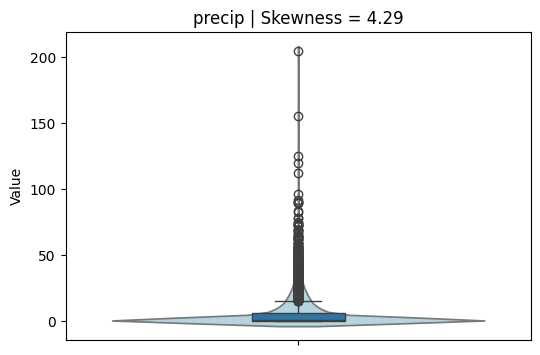

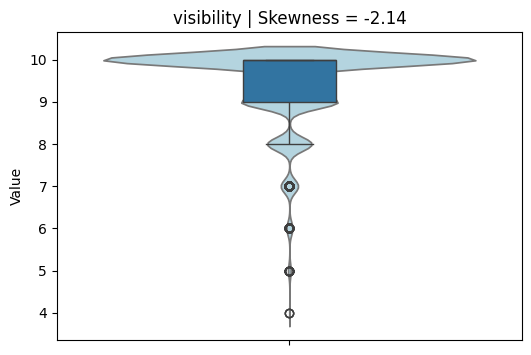

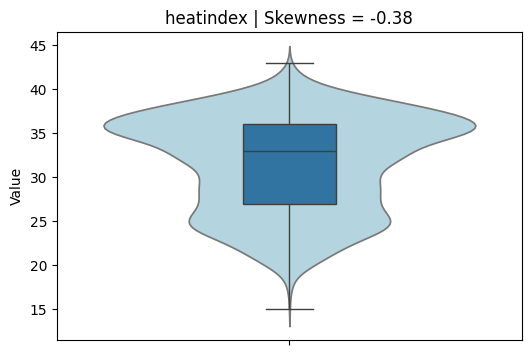

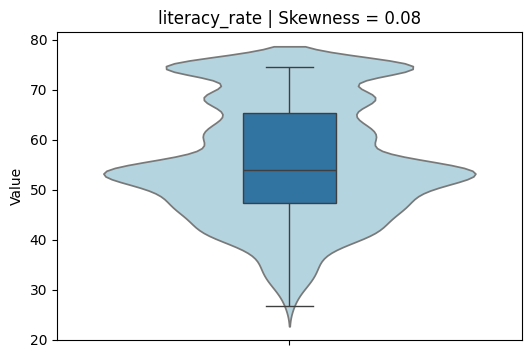

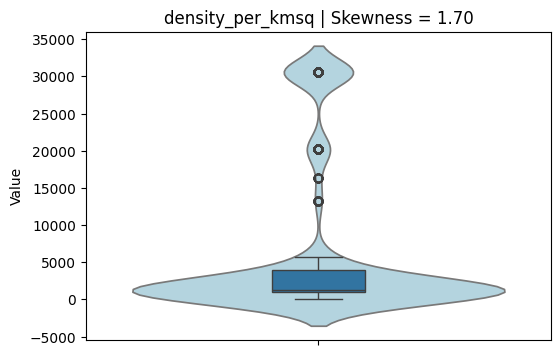

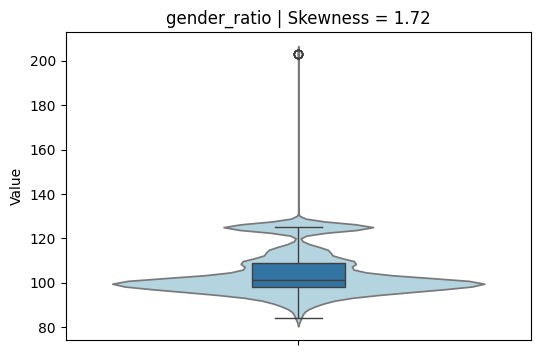

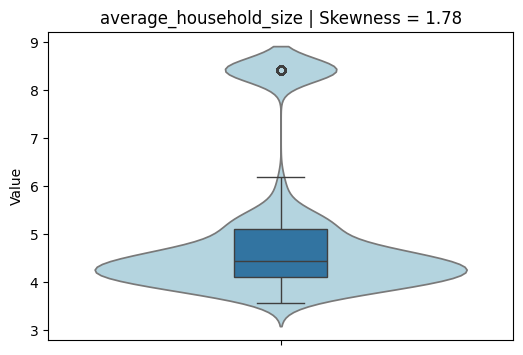

In [150]:
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

- Variabel **precip** memiliki **skewness sangat tinggi (4,29)** dengan **banyak outlier**, yang mencerminkan kejadian hujan ekstrem yang jarang namun bernilai besar.
- Variabel **visibility** menunjukkan **skewness negatif kuat (-2,14)** dengan hanya **beberapa outlier**, kemungkinan terkait kondisi cuaca ekstrem.
- Sebaliknya, **heatindex** dan **literacy_rate** memiliki **distribusi relatif simetris dan stabil**, **tanpa outlier yang signifikan**.
- Variabel **density_per_kmsq**, **gender_ratio**, dan **average_household_size** menunjukkan **skewness positif moderat** dengan **jumlah outlier yang sangat sedikit**, yang kemungkinan merepresentasikan wilayah dengan karakteristik demografis ekstrem.

Secara keseluruhan, outlier yang ditemukan **bersifat alami dan tidak mendominasi data**, sehingga tidak dihapus, melainkan akan ditangani melalui **scaling** yang sesuai pada tahap pemodelan K-Means.

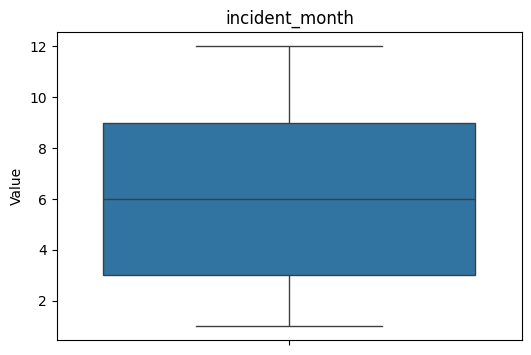

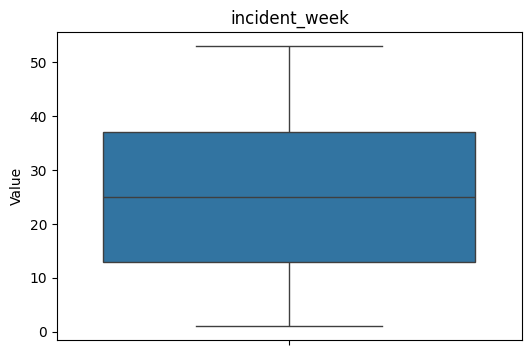

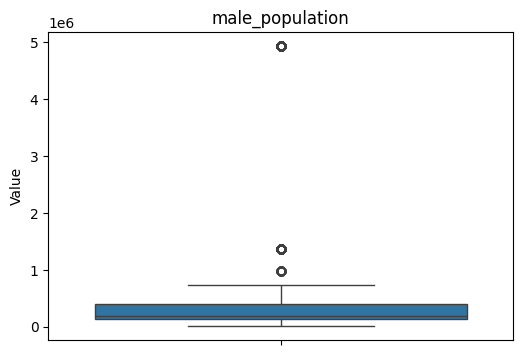

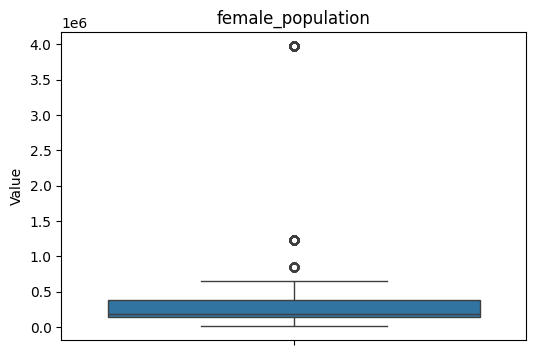

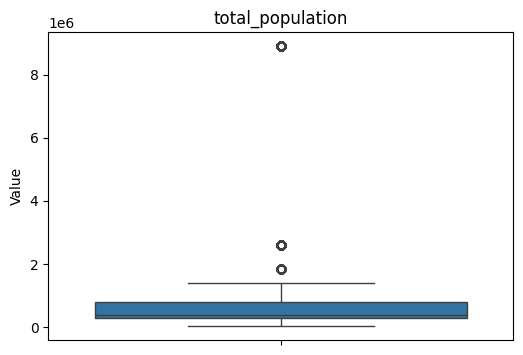

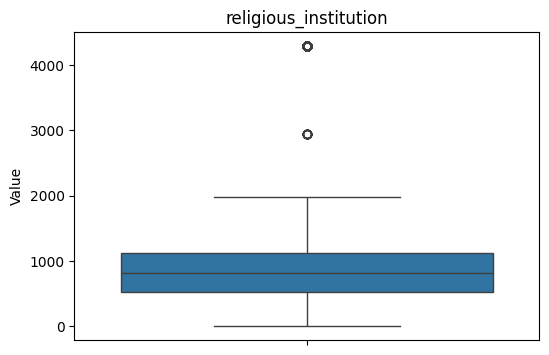

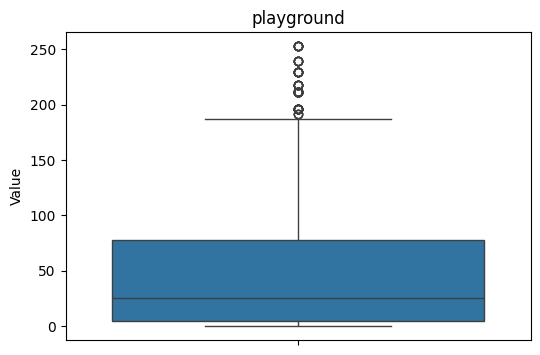

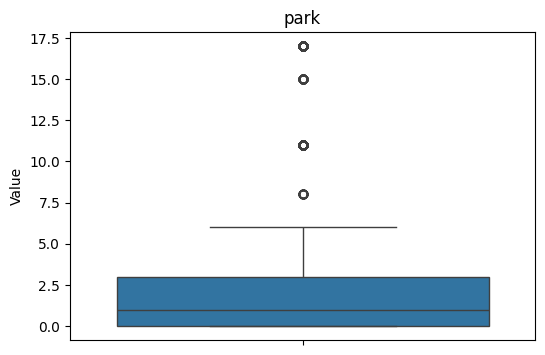

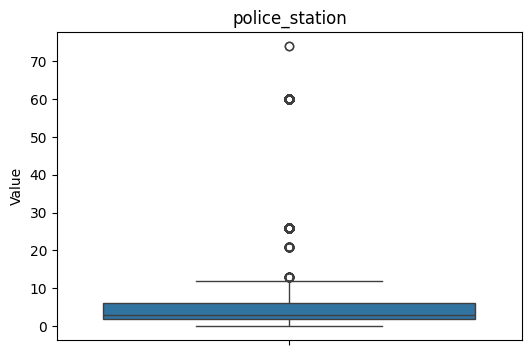

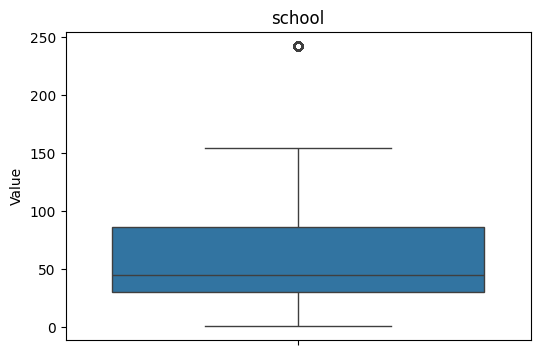

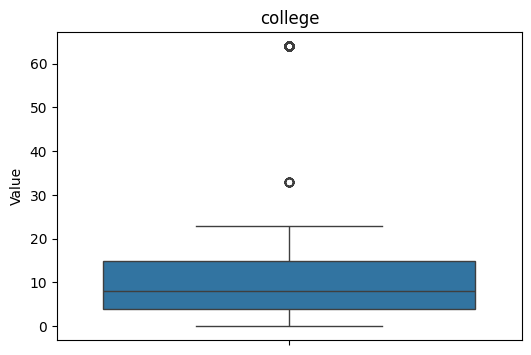

In [151]:
for col in count_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel("Value")
    plt.show()

- **incident_month** dan **incident_week** menunjukkan **distribusi yang relatif stabil tanpa adanya outlier**, menandakan bahwa kejadian kriminal tersebar cukup merata sepanjang waktu dan tidak didominasi oleh periode tertentu.
- Variabel **demografis dan fasilitas publik** seperti **male_population**, **female_population**, **total_population**, **gender_ration**, **religious_institution**, **playground**, **park**, **police_station**, **school**, dan **college** menampilkan **outlier**, yang umumnya merepresentasikan wilayah dengan karakteristik ekstrem, seperti daerah metropolitan atau pusat administrasi dengan kepadatan dan fasilitas yang jauh lebih tinggi dibandingkan wilayah lain.

Namun demikian, **jumlah outlier pada variabel-variabel tersebut relatif sedikit dan tidak mendominasi distribusi** data secara keseluruhan. Oleh karena itu, outlier ini dianggap sebagai nilai valid yang mencerminkan kondisi nyata.

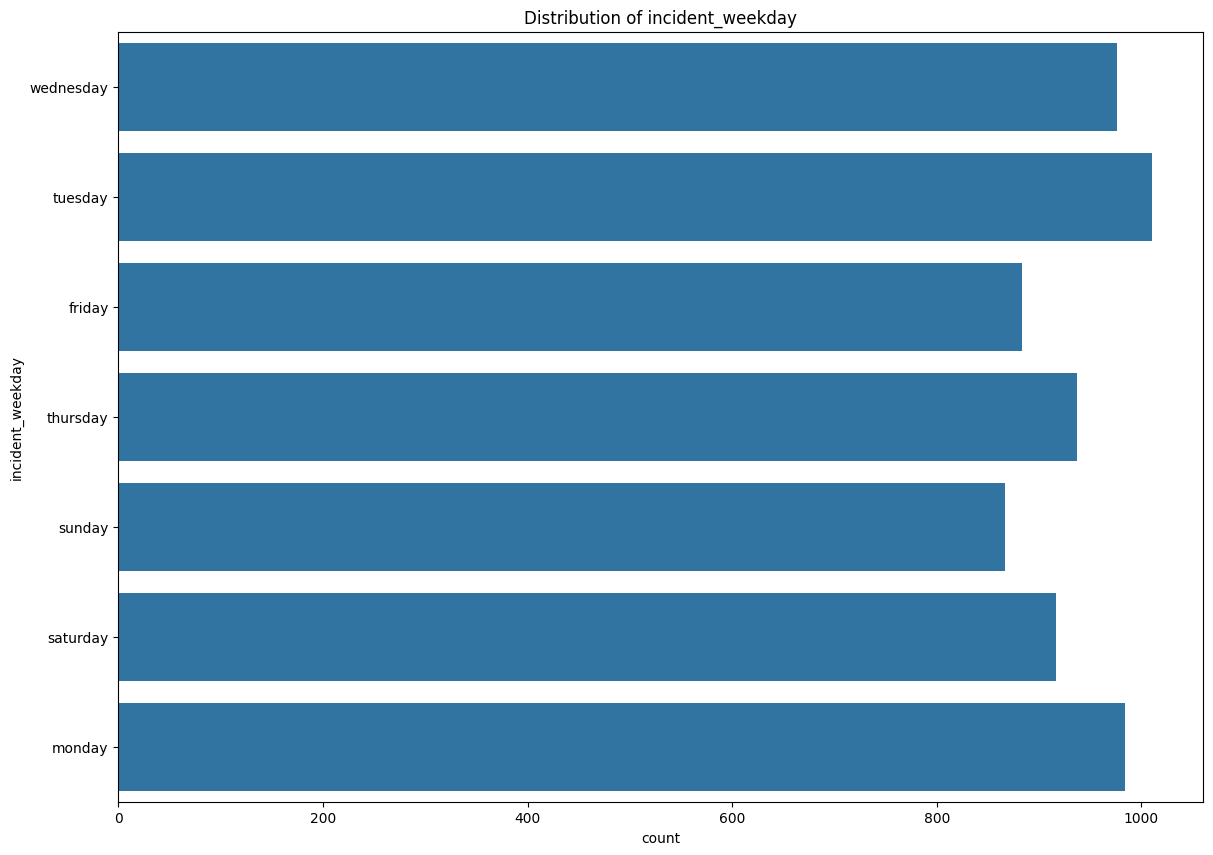

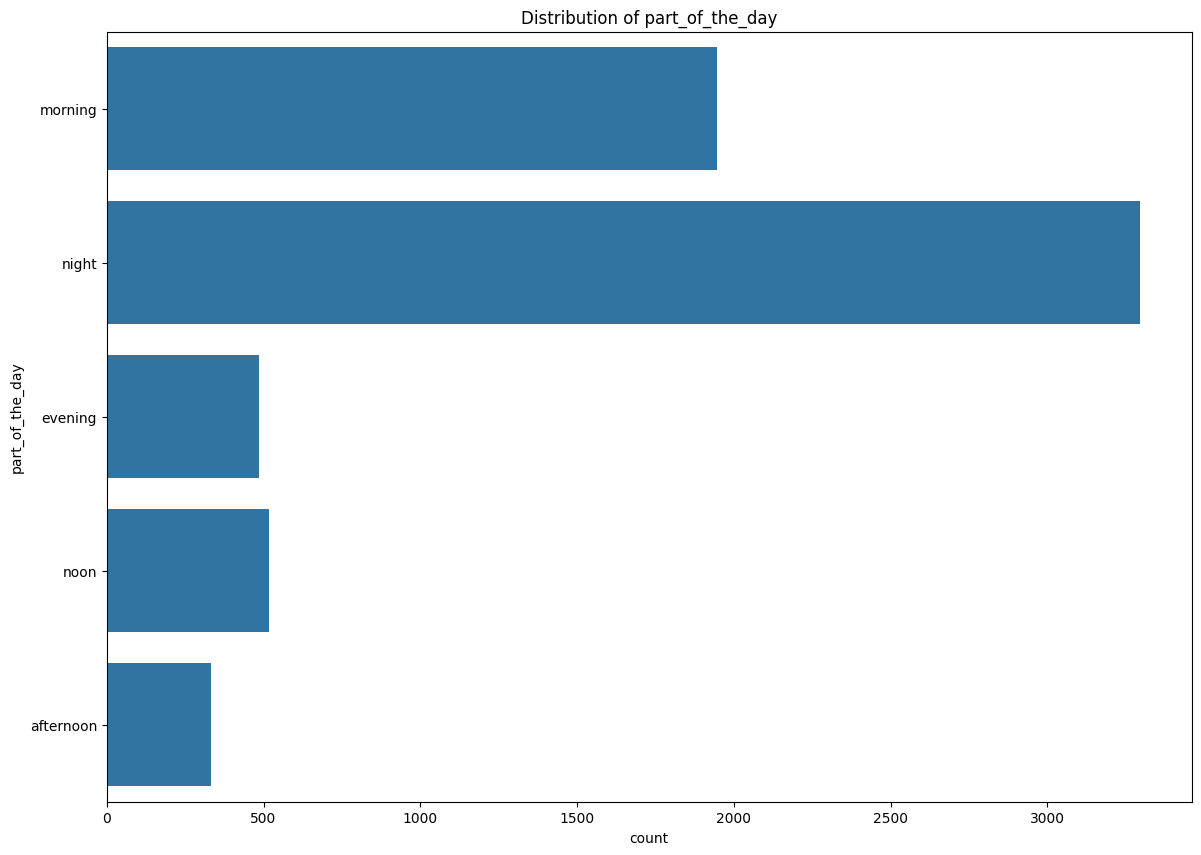

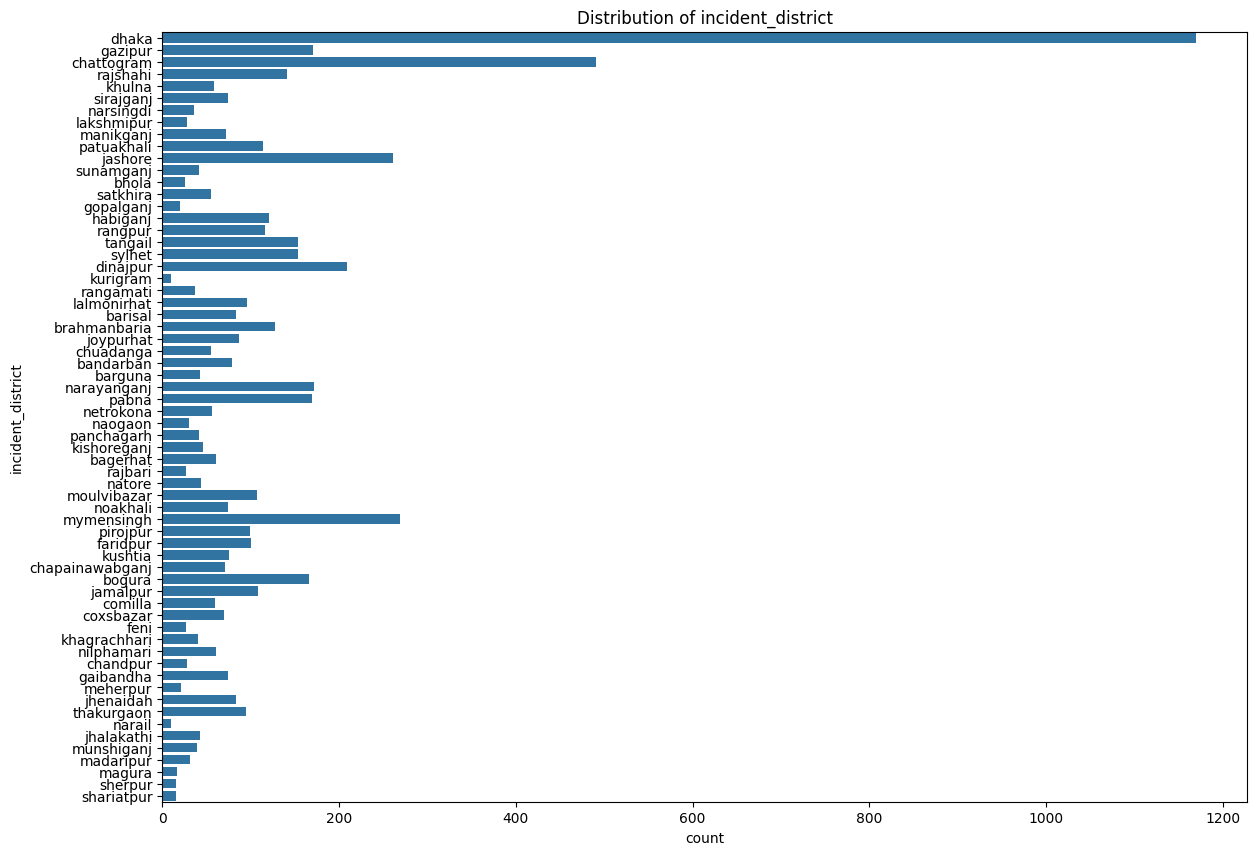

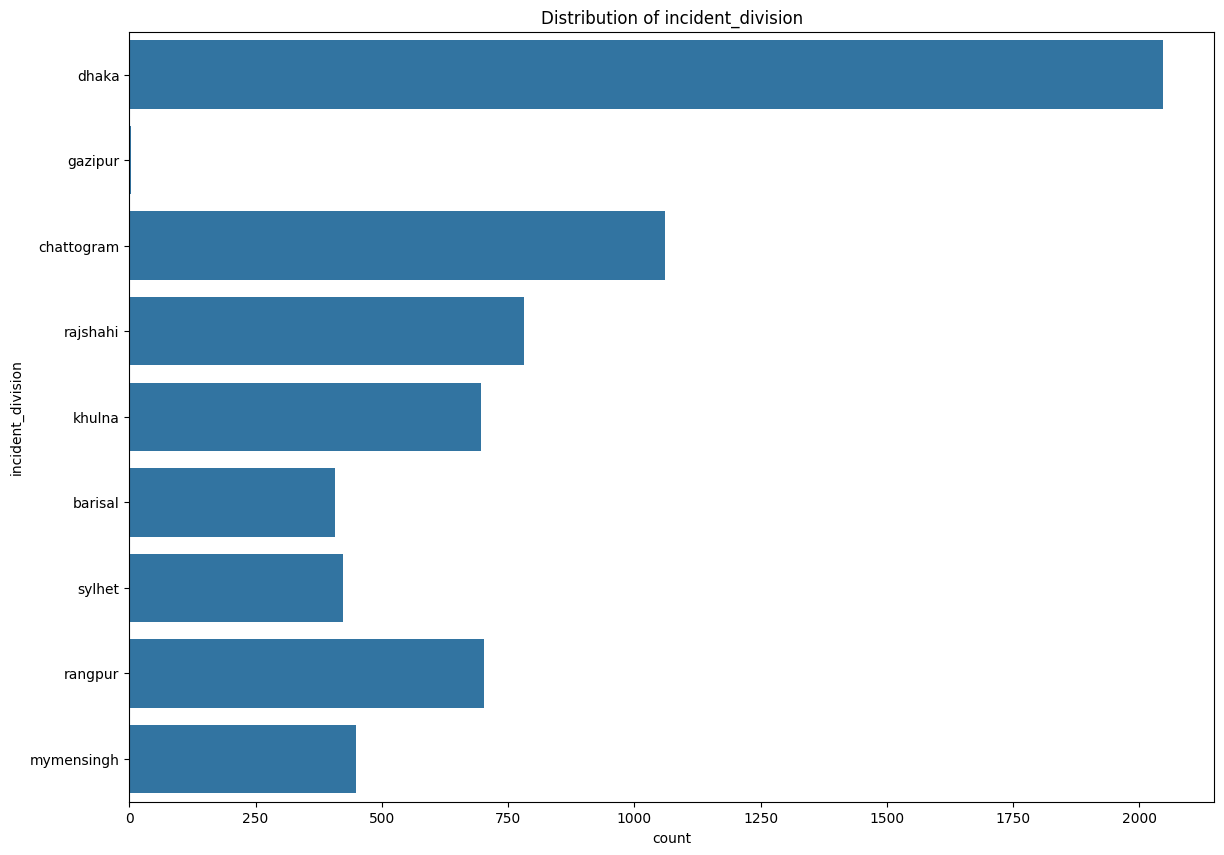

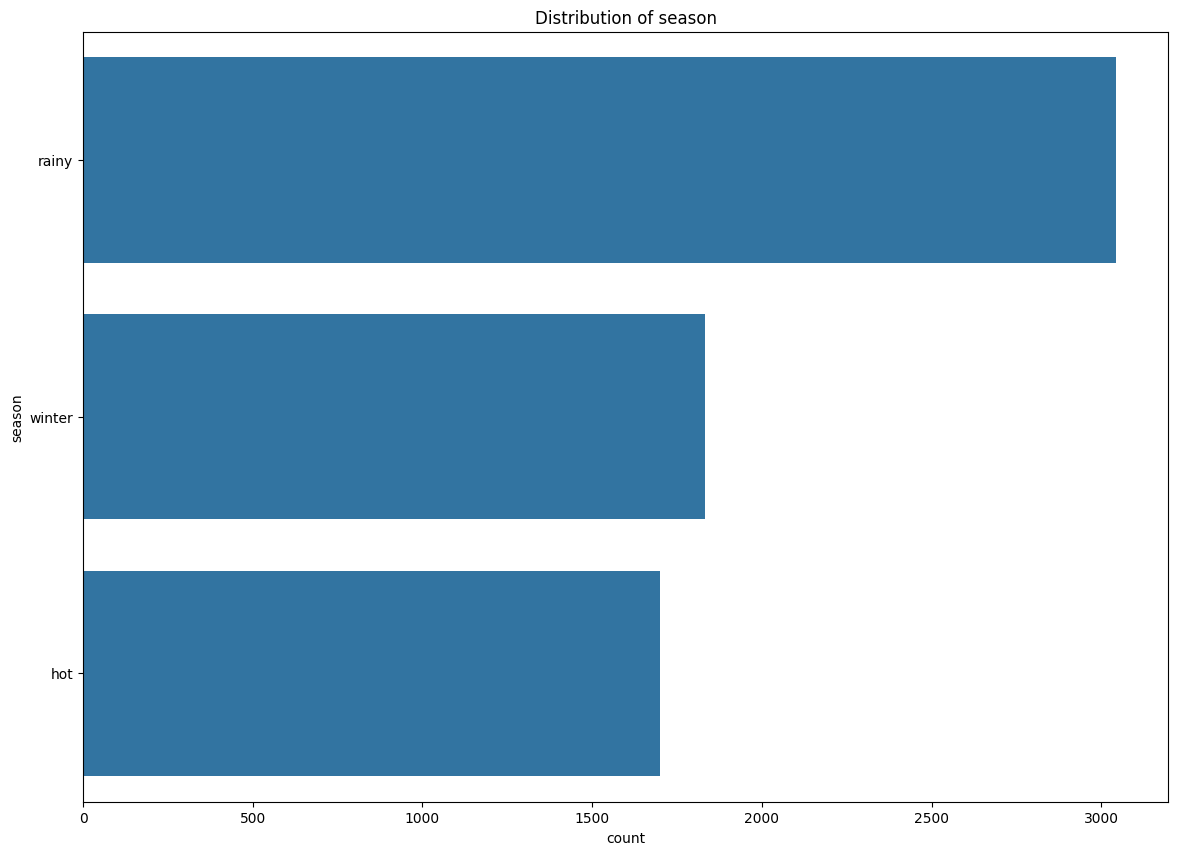

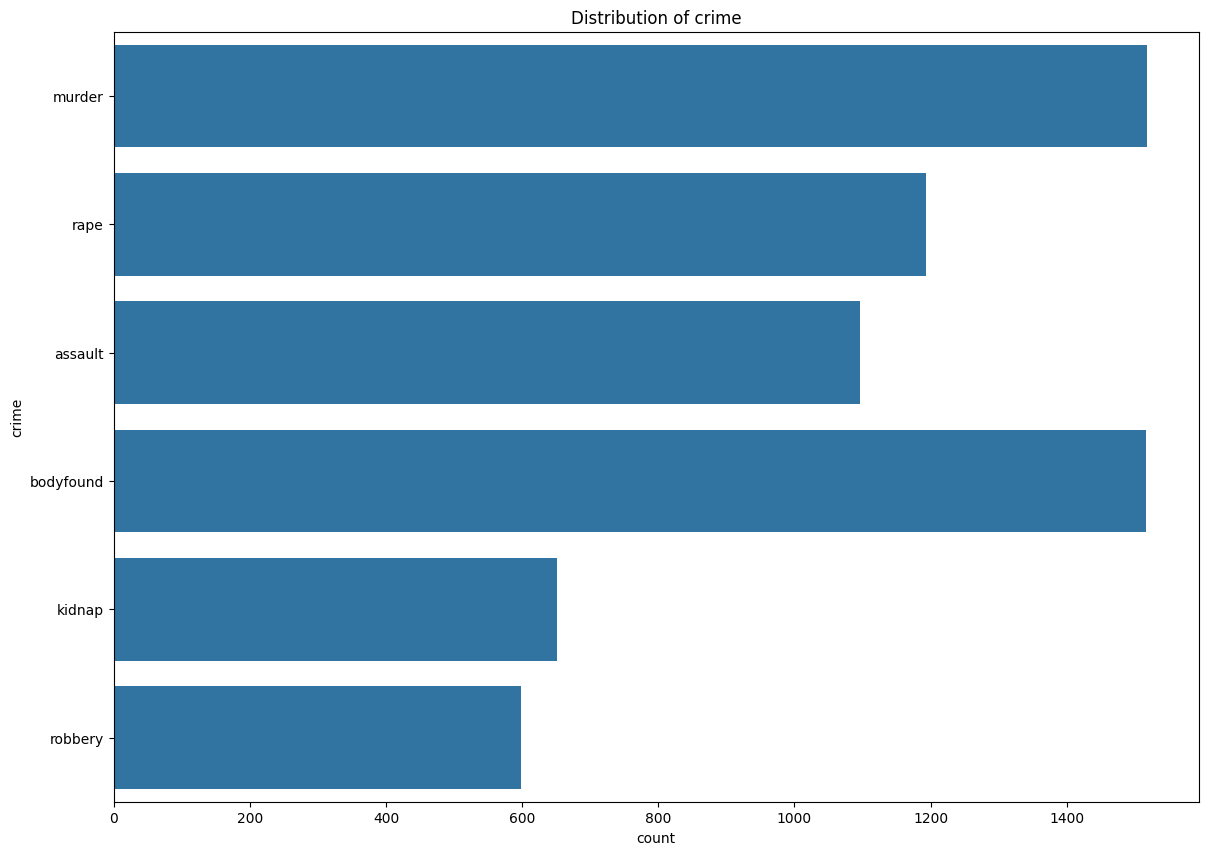

In [152]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(14, 10))
    sns.countplot(data=df, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

- **incident_weekday** terlihat **relatif merata dari Senin hingga Minggu**, dengan **frekuensi tertinggi** terjadi pada **Senin dan Selasa**, serta **frekuensi terendah** pada **Minggu dan Jumat**. Hal ini mengindikasikan bahwa kejadian kriminal tidak terkonsentrasi secara ekstrem pada hari tertentu, meskipun terdapat sedikit variasi antar hari.
- **part_of_the_day** menunjukkan distribusi yang **tidak seimbang**, di mana **kejadian kriminal paling banyak terjadi pada malam hari (lebih dari 3.000 kejadian)** dan **paling sedikit di siang (noon) hari**. Pola ini mengindikasikan bahwa risiko **kriminal cenderung meningkat pada waktu dengan aktivitas rendah**.
- **incident_district** menunjukkan **dominasi** yang sangat jelas pada **Dhaka**, bahkan jumlahnya melebihi 2x dari variabel terbanyak kedua berikutnya.
- **incident_division** memperlihatkan **dominasi** yang sangat jelas pada **Dhaka**, sementara wilayah seperti **Gazipur** memiliki **jumlah kejadian yang sangat kecil hingga hampir tidak terlihat pada visualisasi**. Hal ini mencerminkan perbedaan signifikan dalam kepadatan penduduk, tingkat urbanisasi, dan intensitas aktivitas antar wilayah.
- **season**, kejadian kriminal paling **banyak terjadi pada musim hujan (rainy)**, sedangkan **musim panas (hot) memiliki frekuensi terendah**.
- **crime** menunjukkan bahwa kategori **bodyfound** dan **murder** merupakan **jenis kejahatan yang paling dominan**, sedangkan **robbery menjadi yang paling jarang terjadi, diikuti oleh kidnap**.


### Correlation

#### Correlation Between Numerical Features

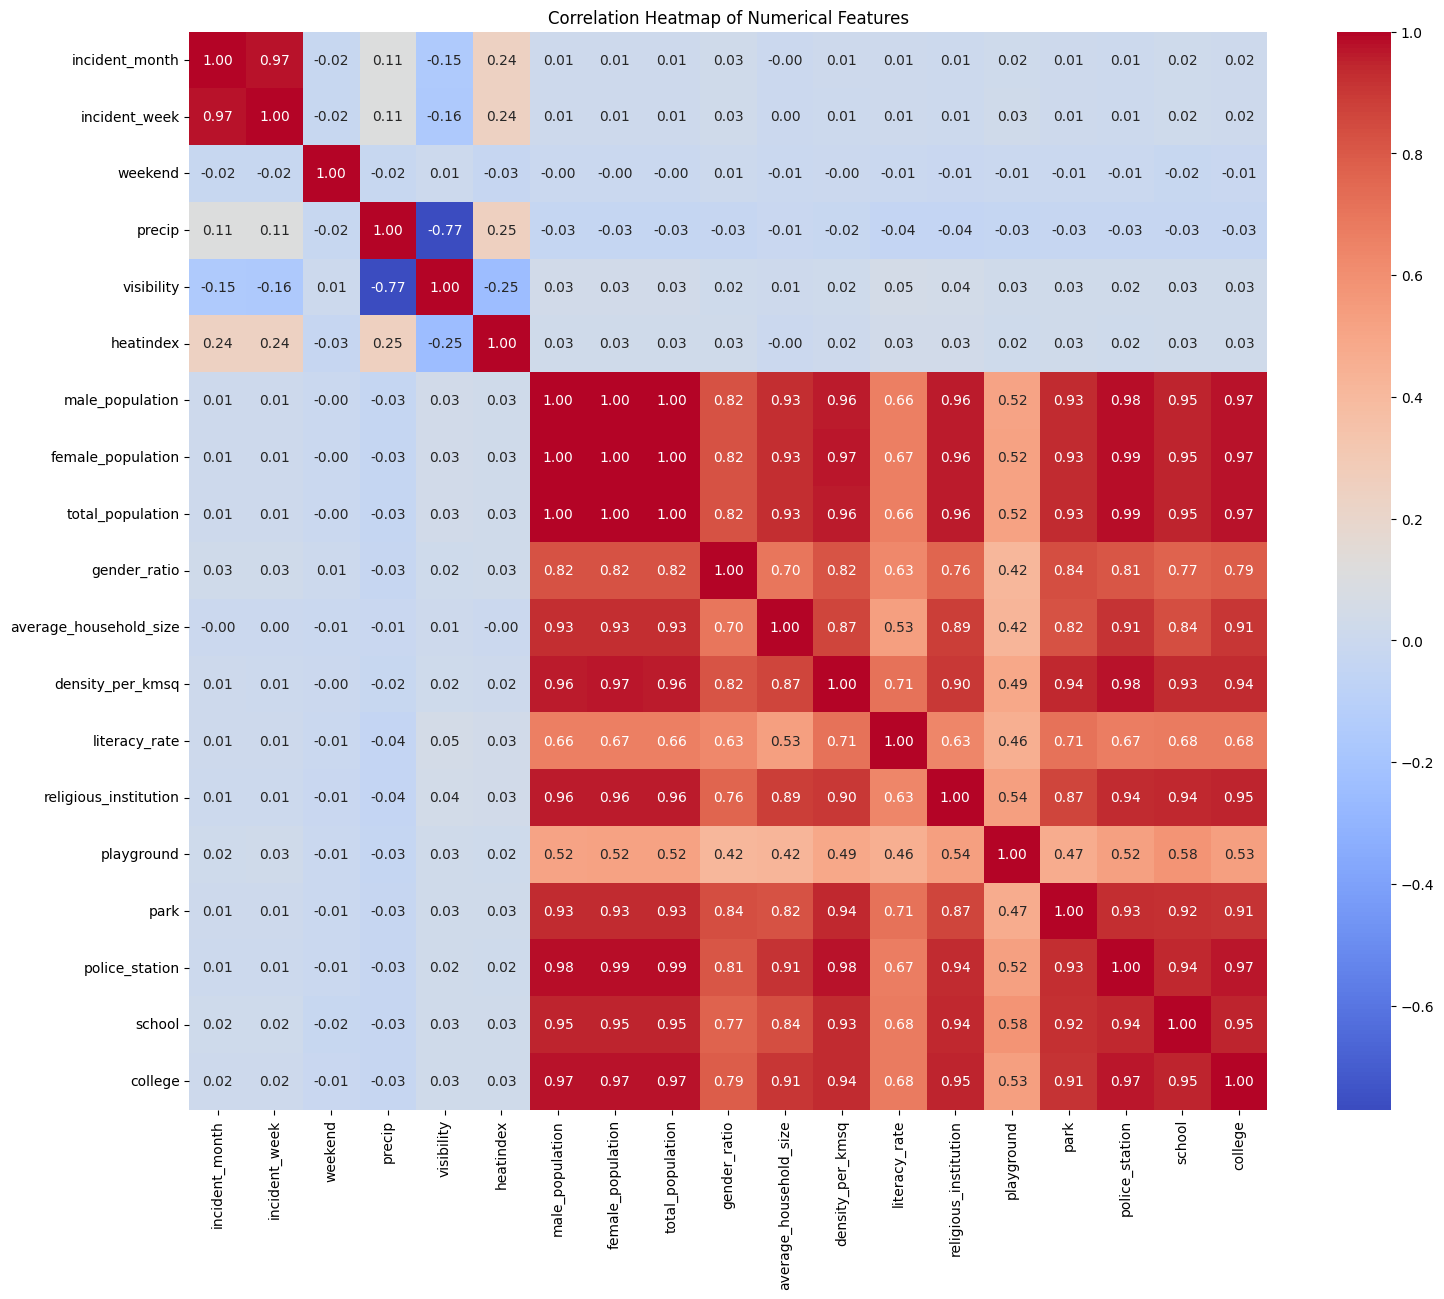

In [153]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

- **Kelompok demografi & infrastruktur (male_population, female_population, total_population, density_per_kmsq, police_station, school, college, park, religious_institution, average_household_size)** memiliki **korelasi yang sangat tinggi (r > 0.9)** satu sama lain. Variabel-variabel ini mengukur skala wilayah yang sama (besar populasi → banyak fasilitas), sehingga terjadi multicollinearity kuat (informasi berulang).   

- Variabel cuaca relatif independen. **precip dan visibility**: **korelasi negatif kuat (-0.77)**. **heatindex dan precip**: **korelasi positif ringan (~0.25)**. **Variabel cuaca hampir tidak berkorelasi dengan demografi & fasilitas**. **Hujan tinggi mempengaruhi jarak pandang** menurun (logis). Cuaca memberikan **dimensi perilaku kriminal yang berbeda** dari demografi.
- **incident_month** dan **incident_week** **berkorelasi sangat tinggi (0.97)**. Sedangkan variabel waktu lainnya hampir tidak berkorelasi dengan variabel lain.

#### Correlation Between Categorical Features

In [154]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

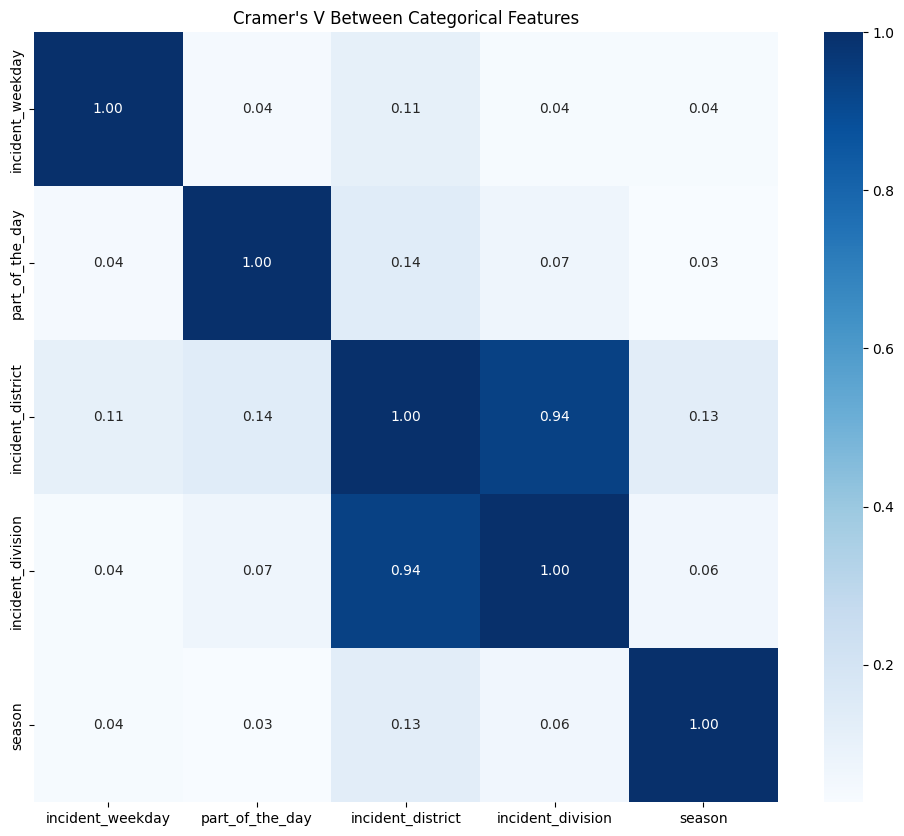

In [155]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = [c for c in cat_cols if c != "crime"]

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(12, 10))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramer's V Between Categorical Features")
plt.show()

Hasil analisis Cramér’s V menunjukkan **hubungan yang sangat kuat antara incident_district dan incident_division**, mengindikasikan redundansi informasi spasial. Oleh karena itu, hanya satu dari kedua variabel tersebut yang digunakan dalam proses clustering. Sementara itu, **variabel temporal seperti incident_weekday, part_of_the_day, dan season menunjukkan hubungan yang lemah satu sama lain,** sehingga memberikan informasi yang saling melengkapi dan relevan untuk pembentukan cluster.

## Feature Selection

**Pemilihan fitur untuk modeling :**
- **Kelompok demografi**   
-> **density_pre_kmsq** karena lebih menggambarkan **intensitas manusia per area** **dan lebih tidak redundan** dibanding total_population yang sangat berkorelasi dengan male_population, female_population, police_station, dan school.   
- **Kelompok infrastruktur**   
-> **police_station** karena merepresentasikan kehadiran aparat dan kontrol keamanan sehingga **relevan langsung ke konteks kriminal**.
- **Variabel Waktu**   
Terdapat korelasi yang kuat antara **incident_month dan incident_week (0.97)**.    
-> **incident_month** dipilih karena **lebih stabil, cukup mewakili waktu makro**, dan lebih representatif dalam menangkap pola musiman.   
-> **weekend juga tidak dimasukkan** karena **diturunkan langsung dari incident_weekday (fungsi deterministik dari incident_weekday)**
- **incident_district** dan **incident_division** juga menunjukkan **ketergantungan yang sangat kuat (≈ 0.94)**   
-> **incident_division** dipilih karena **memiliki jumlah kategori lebih sedikit, lebih stabil setelah encoding**, dan lebih sesuai untuk analisis clustering berbasis jarak.

In [156]:
target_col = 'crime'
num_features = [
    # Environmental
    'precip',
    'visibility',
    'heatindex',
    # Demographic
    'density_per_kmsq',
    'gender_ratio',
    'average_household_size',
    'literacy_rate',
    # Infrastructure
    'police_station'
]

cat_features = [
    # Time
    'incident_month',
    'incident_weekday',
    'part_of_the_day',
    'season',
    # Location (macro-level)
    'incident_division'
]

selected_features = num_features + cat_features
print("Selected Numerical Features:", num_features)
print("Selected Categorical Features:", cat_features)
print("Total Features Used:", len(selected_features))

Selected Numerical Features: ['precip', 'visibility', 'heatindex', 'density_per_kmsq', 'gender_ratio', 'average_household_size', 'literacy_rate', 'police_station']
Selected Categorical Features: ['incident_month', 'incident_weekday', 'part_of_the_day', 'season', 'incident_division']
Total Features Used: 13


In [157]:
X = df[selected_features].copy()

print("Modeling data shape:", X.shape)
X.head()

Modeling data shape: (6574, 13)


,precip,visibility,heatindex,density_per_kmsq,gender_ratio,average_household_size,literacy_rate,police_station,incident_month,incident_weekday,part_of_the_day,season,incident_division
0,6.1,10,32,30551,125,8.42,74.6,60.0,7,wednesday,morning,rainy,dhaka
1,0.0,10,22,30551,125,8.42,74.6,60.0,1,wednesday,night,winter,dhaka
2,0.0,10,25,30551,125,8.42,74.6,60.0,1,tuesday,night,winter,dhaka
3,0.0,10,30,30551,125,8.42,74.6,60.0,3,friday,night,hot,dhaka
4,21.9,9,38,30551,125,8.42,74.6,60.0,8,thursday,night,rainy,dhaka


## Encoding and Scaling

In [158]:
numeric_transformer = Pipeline(steps=[('scaler', RobustScaler())])

categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_features),
 ('cat', categorical_transformer, cat_features)])

In [159]:
X_processed = preprocessor.fit_transform(X)

print("Shape after encoding & scaling:", X_processed.shape)

Shape after encoding & scaling: (6574, 44)


Karena **K-Means berbasis jarak**, maka:
- **kategorikal → OneHotEncoder**
- **numerik → Scaler -> RobustScaler** -> ada outlier dan lebih stabil dibanding StandardScaler

## Optimal Number of Clusters

### Elbow Method (Inertia)

In [160]:
k_range = range(2, 11)

In [161]:
inertia = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)

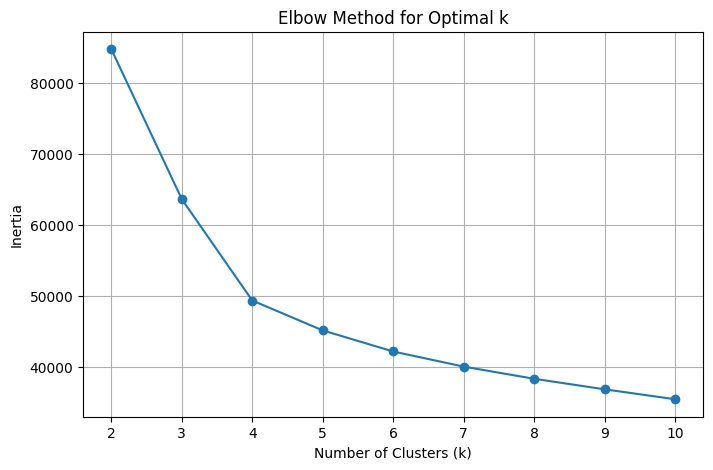

In [162]:
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

Terlihat **penurunan inertia sangat tajam dari k=2 -> k=4**. Setelah **k >= 4**, penurunan mulai **melandai** (**diminishing returns**) yang artinya tidak memberikan peningkatan struktur yang signifikan.   
**-> Titik siku (elbow) paling masuk akal ada di k = 4**

### Silhouette Score

In [163]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_processed)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)

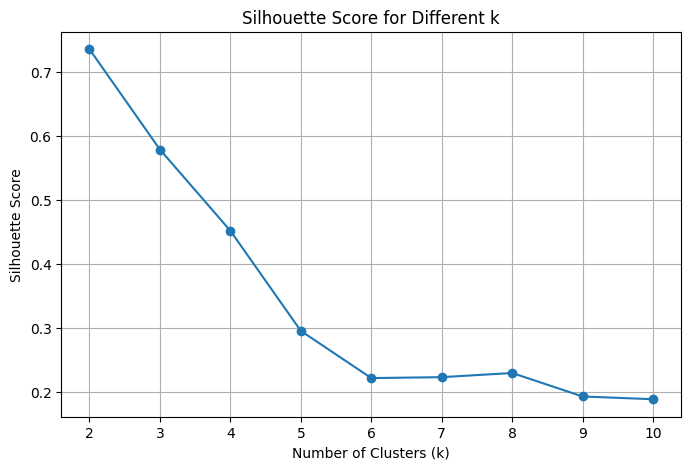

In [164]:
plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.xticks(k_range)
plt.grid(True)
plt.show()

- **Skor tertinggi di k = 2 (~0.74)** → cluster sangat terpisah, tapi **terlalu kasar/oversimplified**
- **k = 4 (~0.45)** masih **menunjukkan pemisahan cluster yang cukup baik**
- **k ≥ 5**: **skor turun drastis** (< 0.3) → **cluster mulai overlap & tidak kompak**

Berdasarkan **metode elbow**, jumlah cluster optimal berada pada **k = 4**, karena setelah titik ini **penurunan nilai inertia mulai melambat secara signifikan**. Hal ini menunjukkan bahwa penambahan jumlah cluster di atas k = 4 tidak lagi memberikan peningkatan struktur cluster yang berarti.

Meskipun **nilai silhouette tertinggi diperoleh pada k = 2**, konfigurasi ini dianggap terlalu sederhana dan belum mampu menangkap variasi karakteristik data secara memadai.

Oleh karena itu, **k = 4 dipilih sebagai jumlah cluster optimal** karena memberikan **keseimbangan terbaik antara kualitas pemisahan cluster dan kemudahan interpretasi**, sehingga lebih sesuai untuk analisis dan profiling cluster.

## Train K-Means

In [165]:
k_optimal = 4

kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_processed)

In [166]:
inertia_final = kmeans_final.inertia_
silhouette_final = silhouette_score(X_processed, cluster_labels)

print(f"Inertia (k={k_optimal}): {inertia_final:.2f}")
print(f"Silhouette Score (k={k_optimal}): {silhouette_final:.3f}")

Inertia (k=4): 49371.54
Silhouette Score (k=4): 0.452


In [167]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

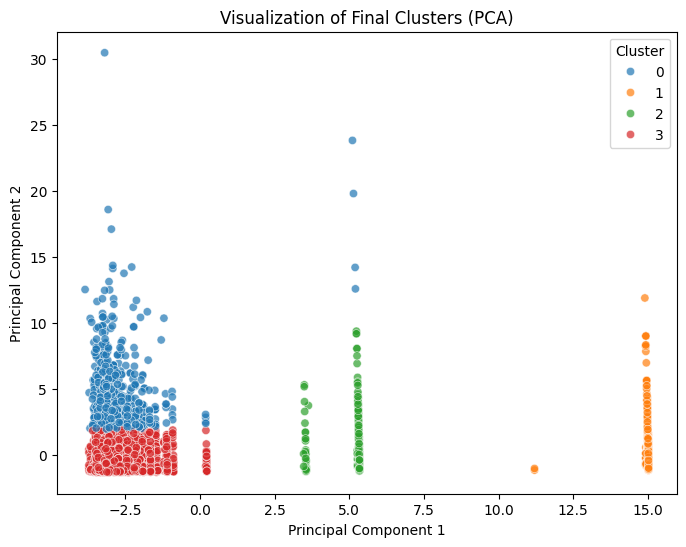

In [168]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.7
)
plt.title('Visualization of Final Clusters (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

**Visualisasi PCA** menunjukkan **pola cluster yang cenderung saling tumpang tindih dan tampak tersegmentasi secara diskrit**. Kondisi ini dipengaruhi oleh penggunaan **one-hot encoding pada fitur kategorikal yang meningkatkan dimensi** data serta oleh sifat **PCA yang hanya memproyeksikan data berdimensi tinggi ke ruang dua dimensi**. Akibatnya, **sebagian informasi struktural antar cluster tidak sepenuhnya terwakili dalam visualisasi**. Oleh karena itu, PCA digunakan semata sebagai alat bantu eksploratif untuk visualisasi, sementara kualitas dan validitas clustering dievaluasi berdasarkan metrik kuantitatif yang lebih relevan, seperti inertia (Elbow Method) dan silhouette score.

## Profile Each Cluster

In [169]:
df_clustered = df.copy()
df_clustered['cluster'] = kmeans_final.labels_

In [170]:
# Numerical Profiling
num_features = ['precip', 'visibility', 'heatindex', 'density_per_kmsq', 'gender_ratio',
                'average_household_size', 'literacy_rate', 'police_station']
num_profile = (
    df_clustered.groupby('cluster')[num_features]
    .agg(['mean', 'median']).round(2)
    )
num_profile

precip        visibility        heatindex        density_per_kmsq  \
          mean median       mean median      mean median             mean   
cluster                                                                     
0        30.95  25.15       7.63    8.0     34.30   35.0          1539.65   
1         4.58   0.80       9.57   10.0     32.01   33.0         30481.58   
2         6.47   0.80       9.36   10.0     30.82   32.0         19783.69   
3         2.38   0.60       9.73   10.0     31.22   32.0          1658.49   

                 gender_ratio        average_household_size         \
          median         mean median                   mean median   
cluster                                                              
0         1084.0       100.38  100.0                   4.51   4.40   
1        30551.0       124.95  125.0                   8.41   8.42   
2        20190.0       109.82  110.0                   4.57   4.60   
3         1108.0       100.83  100.0                   4.42   4.30   

        literacy_rate        police_station         
                 mean median           mean median  
cluster                                             
0               50.87   51.4           3.09    2.0  
1               73.63   74.6          60.03   60.0  
2               68.30   68.8          25.37   26.0  
3               52.12   52.4           3.12    2.0

**Cluster 0: Wilayah Rural–Semi Urban, Curah Hujan Tinggi, Infrastruktur Rendah**
- **Precipitation paling tinggi** -> kejadian banyak terjadi saat hujan lebat.
- **Visibility relatif rendah** -> kondisi cuaca kurang ideal.
- **Density rendah–menengah** -> area tidak padat.
- **Gender ratio & household size** mendekati normal nasional.
- **Literacy rate relatif rendah**.
- **Police station sangat sedikit**.   
Cluster ini merepresentasikan **wilayah kurang berkembang** dengan **akses keamanan rendah**, sering terdampak **kondisi cuaca ekstrem**.   
**-> Potensi kerentanan kriminal berbasis lingkungan**.

**Cluster 1: Urban Core / Metropolitan**
- **Density per km² sangat tinggi** → wilayah sangat padat (urban center).
- **Police station, literacy rate, dan household size paling tinggi**.
- **Precipitation rendah** secara median → cuaca relatif stabil.
- **Visibility tinggi** → kondisi lingkungan baik.   
Cluster ini menggambarkan **kota besar/metropolitan** (mis. Dhaka) dengan **infrastruktur lengkap**, dan **konsentrasi penduduk sangat besar**   
**-> Potensi kriminalitas dipengaruhi faktor kepadatan dan kompleksitas sosial.**

**Cluster 2: Urban Menengah / Secondary City**
- **Density tinggi** tapi di bawah cluster 1.
- **Police station dan literacy rate cukup tinggi**, namun tidak ekstrem.
- Kondisi cuaca relatif normal (**precip & visibility stabil**).
- **Household size sedang**.   
Cluster ini mencerminkan **kota menengah atau pusat regional dengan keseimbangan antara kepadatan, infrastruktur, dan kondisi sosial**   
**-> Berpotensi mengalami kriminalitas transisi (urbanizing areas)**.

**Cluster 3:  Wilayah Rural Stabil**
- **Density rendah** mirip cluster 0, namun:
- **Precipitation lebih rendah**
- **Visibility tinggi**
- **Police station sangat sedikit**
- **Literacy rate sedikit lebih baik** dibanding cluster 0   
Cluster ini menggambarkan wilayah **rural yang relatif stabil**, dengan **kondisi lingkungan baik** tetapi **akses keamanan terbatas**.
**-> Pola kriminalitas lebih jarang dan bersifat lokal.**

In [171]:
# Categorical Profiling
cat_features = ['incident_month', 'incident_weekday', 'part_of_the_day', 'season', 'incident_division']

def get_mode(series):
    return series.mode()[0]

cat_profile = (
    df_clustered
    .groupby('cluster')[cat_features]
    .agg(get_mode)
)

cat_profile

,incident_month,incident_weekday,part_of_the_day,season,incident_division
cluster,,,,,
0,7,thursday,night,rainy,chattogram
1,8,sunday,night,rainy,dhaka
2,4,tuesday,night,rainy,chattogram
3,1,tuesday,night,rainy,dhaka


**Cluster 0**
- Waktu dominan: **Juli, Kamis, malam hari**
- Musim: **Hujan (rainy)**
- Lokasi: **Chattogram**    
-> Kejahatan di cluster ini paling sering terjadi pada **malam hari di musim hujan, dengan konsentrasi wilayah Chattogram**.

**Cluster 1**
- Waktu dominan: **Agustus, Minggu, malam hari**
- Musim: **Hujan (rainy)**
- Lokasi: **Dhaka**    
-> Cluster ini mencerminkan aktivitas **kriminal malam hari, di musim hujan, di wilayah metropolitan Dhaka**, terutama pada **akhir pekan**.

**Cluster 2**
- Waktu dominan: **April, Selasa, malam hari**
- Musim: **Hujan (rainy)**
- Lokasi: **Chattogram**    
-> Pola kriminal **lebih awal dalam tahun**, terjadi pada **hari kerja, malam hari, dan musim hujan** serta **terpusat di Chattogram**.

**Cluster 3**
- Waktu dominan: **Januari, Selasa, malam hari**
- Musim: **Hujan (rainy)**
- Lokasi: **Dhaka**    
-> Cluster ini menggambarkan kejadian kriminal **awal tahun di Dhaka**, tetap **didominasi malam hari dan musim hujan**.

Profil kategorikal menunjukkan bahwa **seluruh cluster didominasi oleh kejadian kriminal pada malam hari dan musim hujan**. **Perbedaan** antar cluster terutama terletak pada **waktu kejadian (bulan dan hari) serta lokasi geografis utama**, yaitu Dhaka dan Chattogram.

In [172]:
# Crime Distribution Per Cluster
crime_dist = (
    df_clustered
    .groupby(['cluster', 'crime'])
    .size()
    .unstack(fill_value=0)
)

crime_percentage = crime_dist.div(crime_dist.sum(axis=1), axis=0) * 100
crime_percentage = crime_percentage.round(2)

dominant_crime = crime_percentage.idxmax(axis=1).to_frame(name='dominant_crime')
crime_percentage

crime,assault,bodyfound,kidnap,murder,rape,robbery
cluster,,,,,,
0,16.56,18.63,9.87,25.96,22.93,6.05
1,17.98,26.92,7.67,15.01,14.20,18.21
2,22.05,27.64,6.21,24.53,13.66,5.90
3,16.10,22.65,10.57,24.10,18.54,8.04


**Cluster 0**   
Kejahatan dominan: **Murder (25.96%)**.   
Diikuti oleh Rape (22.93%) dan Bodyfound (18.63%).Cluster ini cenderung didominasi **kejahatan berat dan kekerasan serius**.

**Cluster 1**   
Kejahatan dominan: **Bodyfound (26.92%)**.   
Robbery cukup tinggi (18.21%) dan Murder relatif lebih rendah (15.01%). Cluster ini cenderung didominasi **kejahatan berat dan kekerasan serius**.

**Cluster 2**   
Kejahatan dominan: **Bodyfound (27.64%)**.      
Murder juga tinggi (24.53%), Assault relatif tinggi (22.05%). Robbery paling rendah (5.90%). Cluster ini mencerminkan kejadian **kriminal serius dengan tingkat kekerasan tinggi**, namun **kejahatan ekonomi relatif jarang**.

**Cluster 3**   
Kejahatan dominan: **Murder (24.10%)**.      
Diikuti oleh Bodyfound (22.65%) dan Rape (18.54%). Serta **Kidnap** sedikit **lebih tinggi dibanding cluster lain (10.57%)**. Cluster ini menunjukkan **kombinasi kejahatan kekerasan dan kejahatan terhadap individu**.

Distribusi jenis kejahatan menunjukkan bahwa setiap cluster memiliki **karakteristik kriminal yang berbeda**, meskipun secara umum **didominasi oleh kejahatan berat seperti murder dan bodyfound.**

In [173]:
# Cluster Size
cluster_size = (
    df_clustered['cluster']
    .value_counts()
    .sort_index()
    .to_frame(name='n_samples')
)
cluster_size

,n_samples
cluster,
0,628
1,873
2,322
3,4751


Hasil clustering dengan K=4 menghasilkan **distribusi ukuran cluster yang tidak seimbang**. **Cluster 3 mendominasi dengan 4.751 kejadian**, menunjukkan **pola kejahatan yang paling umum**, sedangkan **Cluster 2 merupakan cluster terkecil dengan 322 kejadian** yang merepresentasikan **pola kejadian yang lebih spesifik**.

In [174]:
num_profile.columns = ['_'.join(col).strip() for col in num_profile.columns.values]

cluster_summary_full = (
    num_profile
    .join(cat_profile)
    .join(dominant_crime)
    .join(cluster_size)
)

cluster_summary_full

,precip_mean,precip_median,visibility_mean,visibility_median,heatindex_mean,heatindex_median,density_per_kmsq_mean,density_per_kmsq_median,gender_ratio_mean,gender_ratio_median,average_household_size_mean,average_household_size_median,literacy_rate_mean,literacy_rate_median,police_station_mean,police_station_median,incident_month,incident_weekday,part_of_the_day,season,incident_division,dominant_crime,n_samples
cluster,,,,,,,,,,,,,,,,,,,,,,,
0,30.95,25.15,7.63,8.0,34.30,35.0,1539.65,1084.0,100.38,100.0,4.51,4.40,50.87,51.4,3.09,2.0,7,thursday,night,rainy,chattogram,murder,628
1,4.58,0.80,9.57,10.0,32.01,33.0,30481.58,30551.0,124.95,125.0,8.41,8.42,73.63,74.6,60.03,60.0,8,sunday,night,rainy,dhaka,bodyfound,873
2,6.47,0.80,9.36,10.0,30.82,32.0,19783.69,20190.0,109.82,110.0,4.57,4.60,68.30,68.8,25.37,26.0,4,tuesday,night,rainy,chattogram,bodyfound,322
3,2.38,0.60,9.73,10.0,31.22,32.0,1658.49,1108.0,100.83,100.0,4.42,4.30,52.12,52.4,3.12,2.0,1,tuesday,night,rainy,dhaka,murder,4751


- **Cluster 0**: wilayah semi-rural / pinggiran, memiliki **curah hujan tinggi dan kepadatan rendah–menengah**, dengan **akses kepolisian terbatas**, di mana **kejahatan berat (murder) relatif dominan** meski jumlah penduduk tidak padat.
- **Cluster 1**: **perkotaan sangat padat dan teredukasi (urban ekstrem)** dengan **infrastruktur kepolisian kuat**, namun menunjukkan **kompleksitas kriminalitas tinggi**, ditandai dominasi kasus **body found**.
- **Cluster 2**: Wilayah **perkotaan padat menengah**, dengan karakteristik sosial cukup baik, tetapi memperlihatkan **pola kejadian kriminal spesifik dan terlokalisasi**, didominasi oleh **body found**.
- **Cluster 3**: Pola kriminalitas paling umum dan masif dalam dataset, terjadi di wilayah **kepadatan rendah**, dengan **kasus murder dominan**, terutama di **kota besar**, dan merepresentasikan **baseline kondisi kriminal**.

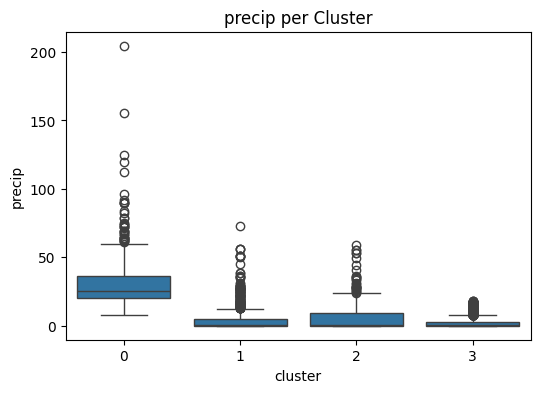

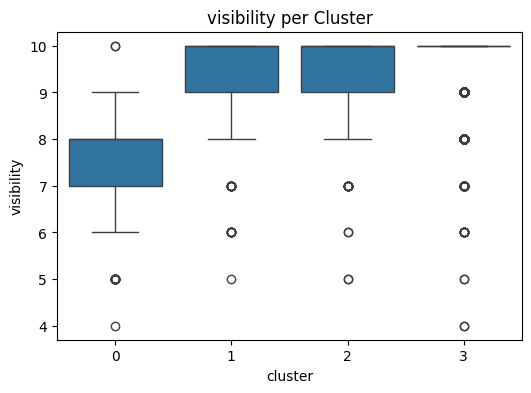

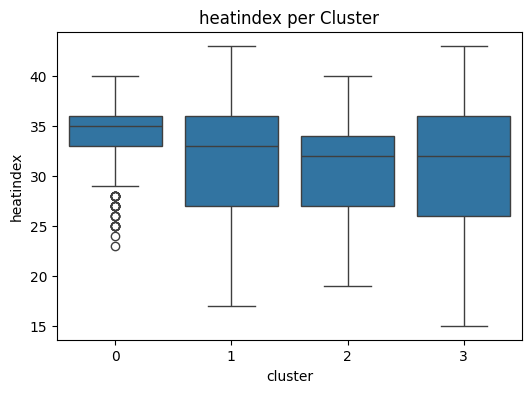

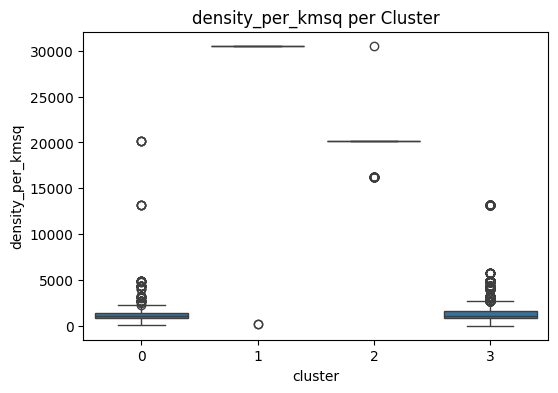

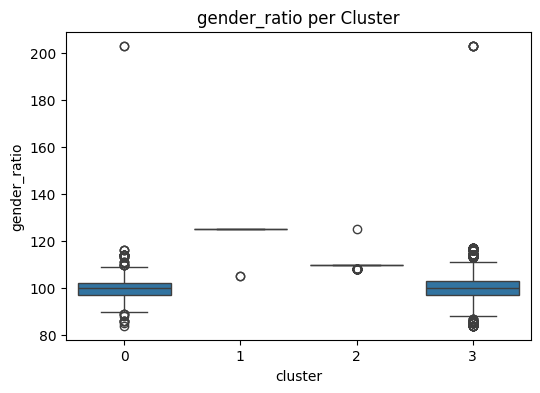

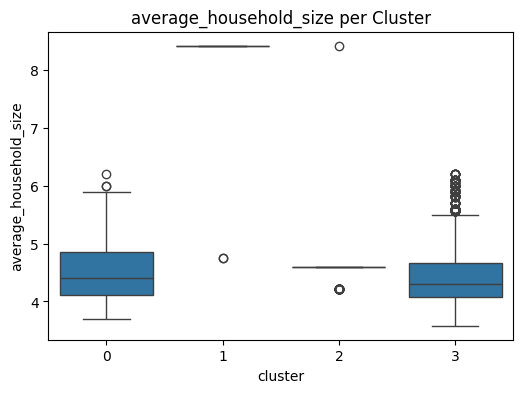

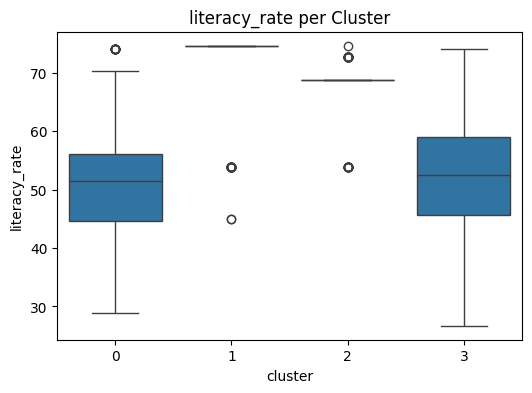

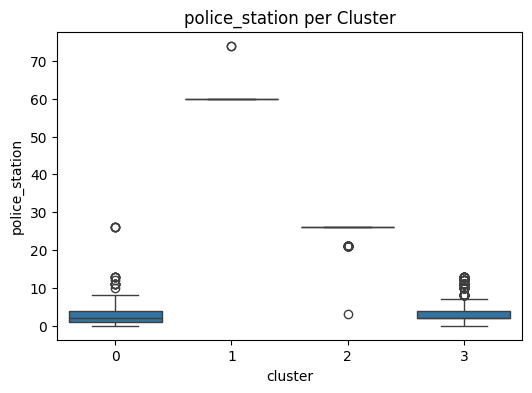

In [175]:
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=col, data=df_clustered)
    plt.title(f'{col} per Cluster')
    plt.show()